In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [41]:
experiment_dir = Path("/dcs/large/u1508153/misdro/normal_bayes_newsvendor")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])


# base_path = "/dcs/large/u1508153/misdro/normal_bayes_newsvendor"

# # load BDRO results and remember to filter (temporary hack for now)
# results_df = pd.read_csv(Path(base_path) / "results.csv", index_col=["uuid", "replication"])
# results_df = results_df.loc[results_df["algorithm"] == "kl_bdro"]

# for setting in ["10000", "10_10", "20_20", "30_30", "50_50"]:
#     experiment_dir = Path(base_path + "_" + setting)
#     assert experiment_dir.exists()
#     df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
#     results_df = pd.concat([results_df, df])

num_total_samples = []
for _, row in results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "our_kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"])
results_df["num_total_samples"] = num_total_samples

results_df = results_df.loc[results_df["dgp"] == "normal"]
results_df

mean_cost     var_cost  \
uuid                                 replication                           
37eeba6a-73ac-420e-ab30-37c857775adc 0            36.436789   639.420992   
                                     1            33.281338   728.528721   
                                     2            40.117484  1119.197381   
                                     3            34.616122   761.561539   
                                     4            35.734344   528.910402   
...                                                     ...          ...   
86353fb5-3c03-429d-ae98-451137aa0368 195          39.955450   494.119382   
                                     196          36.647733   706.312461   
                                     197          45.181029   804.728826   
                                     198          36.311093   531.641970   
                                     199          37.760950   469.531774   

                                                   solution  dgp_time  \
uuid                                 replication                        
37eeba6a-73ac-420e-ab30-37c857775adc 0            32.053977  0.000240   
                                     1            30.624625  0.000446   
                                     2            28.622687  0.000485   
                                     3            33.286875  0.000484   
                                     4            34.235903  0.000412   
...                                                     ...       ...   
86353fb5-3c03-429d-ae98-451137aa0368 195          36.987371  0.000290   
                                     196          33.823548  0.000213   
                                     197          37.645046  0.000218   
                                     198          34.568594  0.000185   
                                     199          40.313952  0.000238   

                                                  likelihood_time  \
uuid                                 replication                    
37eeba6a-73ac-420e-ab30-37c857775adc 0                   0.000022   
                                     1                   0.000030   
                                     2                   0.000034   
                                     3                   0.000031   
                                     4                   0.000040   
...                                                           ...   
86353fb5-3c03-429d-ae98-451137aa0368 195                 0.000169   
                                     196                 0.000094   
                                     197                 0.000096   
                                     198                 0.000092   
                                     199                 0.000103   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
37eeba6a-73ac-420e-ab30-37c857775adc 0                  0.000080    0.040731   
                                     1                  0.000143    0.031963   
                                     2                  0.000140    0.030016   
                                     3                  0.000155    0.041747   
                                     4                  0.000142    0.033874   
...                                                          ...         ...   
86353fb5-3c03-429d-ae98-451137aa0368 195                0.000345    0.248190   
                                     196                0.000206    0.224110   
                                     197                0.000216    0.231314   
                                     198                0.000196    0.225384   
                                     199                0.000231    0.226864   

                                                  setup_time    algorithm  \
uuid                                 replication                            
37eeba6a-73ac-420e

In [42]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
# agg_df
agg_df

mean_cost  \
                                                                                                     mean   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal 0.05    bayes     normal_gamma 5                     5                       39.340752   
                                                  10                    10                      38.238413   
                                                  30                    30                      37.899941   
                   0.06    bayes     normal_gamma 5                     5                       39.356864   
                                                  10                    10                      38.270103   
...                                                                                                   ...   
our_kl_bdro normal 2.50    bayes     normal_gamma 1                     100                     43.633044   
                                                                        900                     47.698549   
                   3.00    bayes     normal_gamma 1                     25                      40.792388   
                                                                        100                     43.749319   
                                                                        900                     48.701124   

                                                                                                           \
                                                                                                      var   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal 0.05    bayes     normal_gamma 5                     5                       33.277351   
                                                  10                    10                      24.345279   
                                                  30                    30                      21.299101   
                   0.06    bayes     normal_gamma 5                     5                       33.470615   
                                                  10                    10                      24.399690   
...                                                                                                   ...   
our_kl_bdro normal 2.50    bayes     normal_gamma 1                     100                     66.742446   
                                                                        900                     68.281335   
                   3.00    bayes     normal_gamma 1                     25                      49.399819   
                                                                        100                     68.601458   
                                                                        900                     75.958743   

                                                                                                  var_cost  \
                                                                                                      mean   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples               
kl_bdro     normal 0.05    bayes     normal_gamma 5                     5                       870.532525   
                                                  10                    10                      797.693870   
                                                  30                    30                      770.553878   
                   0.06    bayes     normal_gamma 5                     5                       866.784353   
                                                  10                    10                      793.967071   
...                                                                                                    ...   
our_kl_bdro normal 2.50    bayes     normal_gamma 1 

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


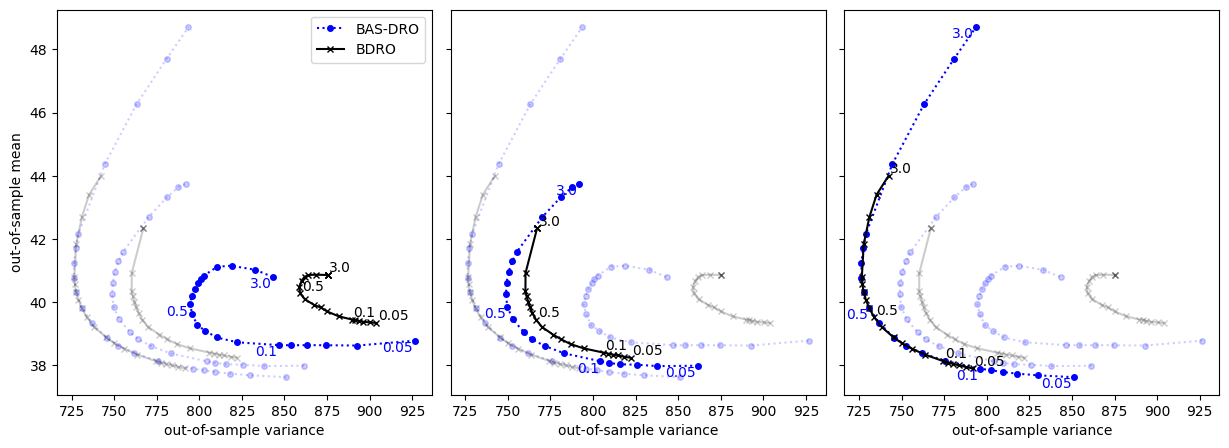

In [72]:
from mis_dro.plot import mean_variance_plot, algorithm_style, AlgorithmColor

from enum import StrEnum

def mean_variance_plot(
    axis,
    df: pd.DataFrame,
    is_labelled: bool = True,
    **kwargs,
) -> None:
    posterior_var = df["var_cost"]["mean"] + df["mean_cost"]["var"]

    # plot mean-variance trade-off
    epsilon_list = list(df.index.get_level_values("epsilon"))
    axis.plot(posterior_var, df["mean_cost"]["mean"], **kwargs, markersize=4)
    # axis.scatter(posterior_var, df["mean_cost"]["mean"], s=100*np.sqrt(np.array(epsilon_list)), **kwargs)
    if is_labelled:
        
        for i, epsilon in enumerate(epsilon_list):
            # if i % 4 == 0:

            if i == 0 or i == len(epsilon_list) - 1 or epsilon in (0.1, 0.5):
                # if line is blue then put text on bottom left
                if kwargs["color"] == AlgorithmColor.our_kl_bdro:
                    ha = "right"
                    va = "top"
                    # offset = -1 if i==0 or i == len(epsilon_list) else -5
                    offset = -1

                # else if line is black then put text on top right
                elif kwargs["color"] == AlgorithmColor.kl_bdro:
                    ha = "left"
                    va = "bottom"
                    # offset = 1 if i==0 or i == len(epsilon_list) else 5
                    offset = 1

                axis.text(
                    posterior_var[:, :, epsilon, :].iloc[0] + offset,
                    df["mean_cost"]["mean"][:, :, epsilon, :].iloc[0],
                    epsilon,
                    ha=ha,
                    va=va,
                    color=kwargs["color"],
                )

class NiceNameDGP(StrEnum):
    normal = "Normal DGP"
    truncated_normal = "Truncated Normal DGP"

# NOTE if you want to visual only one DGP, then uncomment the below lines
# only_dgp = "normal"
# agg_df = agg_df.loc[:, only_dgp, :, :]

compare_col="algorithm"
gb_col="dgp"
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES = [25, 100, 900]
nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby(gb_col)

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
        else:
            alpha = 0.2
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")

            # axes[i, k].set_title(f"{NiceNameDGP[group].value} with {n_total_samples_sqrt**2} samples")
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)

fig.show()

## Solve time

In [5]:
solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples"]).agg({"solve_time": ["mean"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df

solve_time                                         
                        mean                                         
dgp                   normal             truncated_normal            
algorithm            kl_bdro our_kl_bdro          kl_bdro our_kl_bdro
num_total_samples                                                    
25                  0.010445    0.012513         0.010417    0.012652
100                 0.027010    0.023635         0.026807    0.024408
900                 0.253641    0.396567         0.255681    0.395181

In [6]:
print(solve_time_df.to_latex())

\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{4}{r}{solve_time} \\
 & \multicolumn{4}{r}{mean} \\
dgp & \multicolumn{2}{r}{normal} & \multicolumn{2}{r}{truncated_normal} \\
algorithm & kl_bdro & our_kl_bdro & kl_bdro & our_kl_bdro \\
num_total_samples &  &  &  &  \\
\midrule
25 & 0.010445 & 0.012513 & 0.010417 & 0.012652 \\
100 & 0.027010 & 0.023635 & 0.026807 & 0.024408 \\
900 & 0.253641 & 0.396567 & 0.255681 & 0.395181 \\
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [7]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_kl_bdro_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_kl_bdro_constant("normal_gamma", theta_posterior)

dgp = "normal"
posterior = "normal_gamma"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_kl_bdro_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

(0.04688086567534833, 0.0)

In [8]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [9]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [10]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

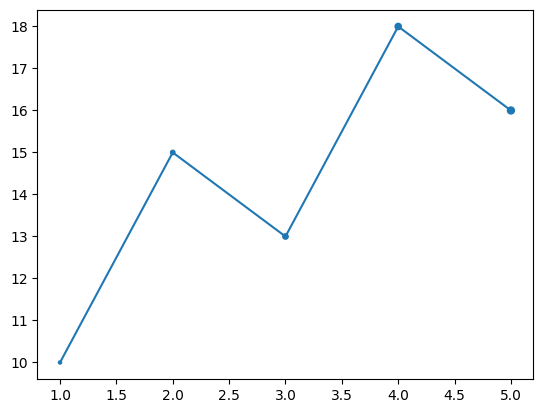

In [11]:
# Data
x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 18, 16]
sizes = [5, 10, 15, 20, 25]

# Plot
plt.scatter(x, y, marker='o', s=sizes)
plt.plot(x, y, marker='o', markersize=0)
plt.show()